### Generate SIMLIB file for SNANA with specific sky location from GW skymap

In [1]:
import opsimsummaryv2 as opsim
import pandas as pd
import numpy as np
import healpy as hp
# import ligo.skymap functions
import ligo.skymap.plot
from ligo.skymap.io.fits import read_sky_map
from ligo.skymap.moc import uniq2nest, uniq2pixarea
import ligo.skymap.postprocess as postprocess
# import astropy functions
from astropy.coordinates import SkyCoord
from astropy.cosmology import Planck18 as cosmo
from astropy import units as u
from astropy.cosmology import z_at_value
from matplotlib import pyplot as plt

/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/fred/oz016/bgao_kn/rubin/lib/python3.10/site-packages/ligo/lw/lsctables.py:89: UserWarning: Wswiglal-redir-stdio:

SWIGLAL standard output/error redirection is enabled in IPython.
This may lead to performance penalties. To disable locally, use:

with lal.no_swig_redirect_standard_output_error():
    ...

To disable globally, use:

lal.swig_redirect_standard_output_error(False)

Note however that this will likely lead to error messages from
LAL functions being either misdirected or lost when called from
Jupyter notebooks.

To suppress this warning, use:

import warnings
warnings.filterwarnings("ignore", "Wswiglal-redir-stdio")
import lal

  import lal


Select several sky positions from GW skymap

In [2]:
class MyOpsimSurvey(opsim.OpSimSurvey):
    def sample_coordinates(self,
                           ra,
                           dec,
                           nsides=256,
                           is_deg=True,
                           nworkers=10):
        """
        Get healpy pixel indices for given RA and Dec coordinates. And select these healpy pixels as fields.
        """

        N_fields = len(ra)
        if len(ra) > len(self.hp_rep):
            raise ValueError(
                f"N_fields ({len(ra)}) > survey fields ({len(self.hp_rep)})"
            )
        
        if is_deg:
            phi = np.radians(ra)
            theta = np.radians(90.0-dec)

        pix = hp.ang2pix(nsides, theta, phi, nest=True)
        self._survey = self.hp_rep[self.hp_rep.index.isin(pix)].copy()
        self._survey.reset_index(inplace=True)
        self._survey.attrs = self.hp_rep.attrs.copy()
        self._survey.attrs["N_fields"] = N_fields

        if self.host is not None:
            print("Compute survey hosts")
            self._survey_hosts = self.get_survey_hosts(nworkers=nworkers)
    

In [2]:
sim_id = 6
# MOC skymap for high resolution
skymap = read_sky_map(f'/fred/oz016/bgao_kn/data/bns_skymap/{sim_id}.fits', moc=True)
# Load with nest map
nest_map, meta = read_sky_map(f'/fred/oz016/bgao_kn/data/bns_skymap/{sim_id}.fits', nest=True)
print("Distance mean:", meta.get('distmean'), "Mpc\nDistance std:", meta.get('diststd'), 'Mpc')
skymap[:5]

Distance mean: 613.5378306750999 Mpc
Distance std: 207.6096169175938 Mpc


UNIQ,PROBDENSITY,DISTMU,DISTSIGMA,DISTNORM
,1 / sr,Mpc,Mpc,1 / Mpc2
int64,float64,float64,float64,float64
1024,3.0149809450637874e-05,342.1529339888736,395.11906866189776,3.884067583127525e-06
1025,2.3112109380115745e-05,324.72294779799995,413.00456237012463,3.910629070567796e-06
1026,0.003064224602111363,344.3217899176964,257.81255245410193,5.472498341264127e-06
1027,2.4842884892086737e-05,213.78531218490258,467.7912264272031,4.655290277241597e-06
1028,5.746089183533391e-05,108.2321960650648,440.0148534250174,7.089989674642782e-06


In [3]:
def sample_sky_from_moc(uniq, probdensity, n_samples, level=0.9, within=True):
    # uniq = skymap_moc['UNIQ']
    # probdensity = skymap_moc['PROBDENSITY']
    # distmu = skymap_moc['DISTMU']
    # distsigma = skymap_moc['DISTSIGMA']
    # distnorm = skymap_moc['DISTNORM']
    uniq = np.asarray(uniq, dtype=np.int64)
    probdensity = np.asarray(probdensity, dtype=float)

    # 1) UNIQ -> order, ipix, nside
    order, ipix = uniq2nest(uniq)

    # 2) caculate pixel area
    dA = uniq2pixarea(uniq)
    # 3) calculate pixel probability
    dP = probdensity * dA
    # 4) calculate credible levels
    cls = postprocess.find_greedy_credible_levels(
        dP, probdensity
    )
    cls = np.where(cls>1, 1.0, cls)
    idx_sorted = np.argsort(probdensity)[::-1]
    cls_sorted = cls[idx_sorted]

    if within:
        mask = cls_sorted <= level
        # if np.any(cls > level):
        #     first_above = idx_sorted[np.argmax(cls > level)]
        #     # print(first_above)
        #     mask[first_above] = True
        cred_idx_sorted = idx_sorted[mask]
    else:
        mask = cls_sorted >= level
        # if np.any(cls < level):
        #     last_below = np.argmin(cls < level) - 1
        #     # print(last_below)
        #     mask[last_below] = True
        cred_idx_sorted = idx_sorted[mask]
    
    if within:
        p_cred = dP[cred_idx_sorted]
        p_cred /= p_cred.sum()
        cdf_cred = np.cumsum(p_cred)
        cdf_cred[-1] = 1.0

        # 5) sample pixels according to p
        u = np.random.random(size=n_samples)
        j = np.searchsorted(cdf_cred, u)
        pix_indices = cred_idx_sorted[j]
    else:
        pix_indices = np.random.choice(cred_idx_sorted, size=n_samples, replace=False)

    # 5) calculate RA, Dec for sampled pixels
    ras  = np.empty(n_samples, dtype=float)
    decs = np.empty(n_samples, dtype=float)

    sample_order = order[pix_indices]
    sample_ipix  = ipix[pix_indices]

    # group by order to speed up
    for k in np.unique(sample_order):
        m = (sample_order == k)
        this_ipix  = sample_ipix[m]
        this_nside = 2 ** k
        theta, phi = hp.pix2ang(this_nside, this_ipix, nest=True)
        ras[m]  = np.degrees(phi)
        decs[m] = 90.0 - np.degrees(theta)

    # caculate credible level of sampled pixels
    credible_levels = cls_sorted[np.where(np.isin(idx_sorted, pix_indices))[0]]

    return ras, decs, credible_levels

In [ ]:
def uniq_to_order_ipix(uniq):
    # UNIQ -> order, ipix
    uniq = np.asarray(uniq, dtype=np.int64)
    order = np.floor(np.log2(uniq / 4.0) / 2.0).astype(int)
    ipix  = uniq - 4 * (4 ** order)
    return order, ipix

def sample_sky_from_moc_0(uniq, probdensity, n_samples, level=0.9, within=True):
    # uniq = skymap_moc['UNIQ']
    # probdensity = skymap_moc['PROBDENSITY']
    # distmu = skymap_moc['DISTMU']
    # distsigma = skymap_moc['DISTSIGMA']
    # distnorm = skymap_moc['DISTNORM']
    uniq = np.asarray(uniq, dtype=np.int64)
    probdensity = np.asarray(probdensity, dtype=float)

    # 1) UNIQ -> order, ipix, nside
    order, ipix = uniq2nest(uniq)

    # 2) caculate pixel area
    omega_pix = uniq2pixarea(uniq)
    dA = uniq2pixarea(uniq)
    dP = probdensity * dA
    cls = 100 * postprocess.find_greedy_credible_levels(
        dP, skymap["PROBDENSITY"]
    )
    cls = np.where(cls>100, 100, cls)
    
    # 3) calculate pixel probability
    p = probdensity * omega_pix
    p /= p.sum()

    # 4) find credible set within level
    idx_sorted = np.argsort(p)[::-1]
    p_sorted = p[idx_sorted]
    cum = np.cumsum(p_sorted)

    if within:
        mask = cum <= level
        if np.any(cum > level):
            first_above = np.argmax(cum > level)
            # print(first_above)
            mask[first_above] = True
        cred_idx_sorted = idx_sorted[mask]
    else:
        mask = cum >= level
        if np.any(cum < level):
            last_below = np.argmin(cum < level) - 1
            # print(last_below)
            mask[last_below] = True
        cred_idx_sorted = idx_sorted[mask]
    
    if within:
        p_cred = p[cred_idx_sorted]
        p_cred /= p_cred.sum()
        cdf_cred = np.cumsum(p_cred)
        cdf_cred[-1] = 1.0

        # 5) sample pixels according to p
        u = np.random.random(size=n_samples)
        j = np.searchsorted(cdf_cred, u)
        pix_indices = cred_idx_sorted[j]
    else:
        pix_indices = np.random.choice(cred_idx_sorted, size=n_samples, replace=False)

    # 5) calculate RA, Dec for sampled pixels
    ras  = np.empty(n_samples, dtype=float)
    decs = np.empty(n_samples, dtype=float)

    sample_order = order[pix_indices]
    sample_ipix  = ipix[pix_indices]

    # group by order to speed up
    for k in np.unique(sample_order):
        m = (sample_order == k)
        this_ipix  = sample_ipix[m]
        this_nside = 2 ** k
        theta, phi = hp.pix2ang(this_nside, this_ipix, nest=True)
        ras[m]  = np.degrees(phi)
        decs[m] = 90.0 - np.degrees(theta)

    # caculate credible level of sampled pixels
    credible_levels = cum[np.where(np.isin(idx_sorted, pix_indices))[0]]

    return ras, decs, credible_levels

In [5]:
# Select 10 samples from the MOC skymap
N = 10
uniq = skymap['UNIQ']
probdensity = skymap['PROBDENSITY']
ra, dec, credible_levels = sample_sky_from_moc(skymap['UNIQ'], skymap['PROBDENSITY'], N, level=0.9, within=True)
dist = np.random.normal(loc=meta.get('distmean'), scale=meta.get('diststd'), size=N)
redshift = z_at_value(cosmo.luminosity_distance, dist * u.Mpc).value
print("Sampled RA:", ra)
print("Sampled Dec:", dec)
print("Sampled distances (Mpc):", dist)
print("Sampled redshifts:", redshift)
print("Sampled credible levels:", credible_levels)

Sampled RA: [106.63043478  29.8828125  177.71484375 162.25961538 185.625
 183.1640625  180.         142.08661417 179.296875   188.4375    ]
Sampled Dec: [-55.87335044  11.56741759 -18.20995686 -51.25580695 -36.0535886
 -11.87218709  -9.89685344 -42.21036984  23.31795707 -29.65601354]
Sampled distances (Mpc): [751.84488185 523.22541173 733.61579326 193.13856286 528.87339139
 929.44755917 667.62290462 897.95193812 474.44603603 645.599373  ]
Sampled redshifts: [0.15277652 0.10929213 0.14938428 0.04224243 0.11039253 0.18521823
 0.13699943 0.17954218 0.09972869 0.13282883]
Sampled credible levels: [0.07075701 0.14197544 0.19267344 0.37789158 0.40184146 0.4071743
 0.49347581 0.56193348 0.65022238 0.80325057]


In [8]:
# Add True location
injections = pd.read_csv('/fred/oz016/bgao_kn/ML+GW+KN/dataset/O5_sim_bns/injections_final.csv')
index = np.where(injections['simulation_id'] == sim_id)[0][0]
distance_inj = injections.iloc[index]['distance']
# True redshift
z = z_at_value(cosmo.luminosity_distance, distance_inj * u.Mpc)

ra = np.append(ra, 169.471101)
dec = np.append(dec, -31.126445)
redshift = np.append(redshift, z.value)
print("Added true location:\n")
print("Sampled RA:", ra)
print("Sampled Dec:", dec)
print("Sampled redshifts:", redshift)

Added true location:

Sampled RA: [106.63043478  29.8828125  177.71484375 162.25961538 185.625
 183.1640625  180.         142.08661417 179.296875   188.4375
 169.471101  ]
Sampled Dec: [-55.87335044  11.56741759 -18.20995686 -51.25580695 -36.0535886
 -11.87218709  -9.89685344 -42.21036984  23.31795707 -29.65601354
 -31.126445  ]
Sampled redshifts: [0.15277652 0.10929213 0.14938428 0.04224243 0.11039253 0.18521823
 0.13699943 0.17954218 0.09972869 0.13282883 0.06761342]


In [9]:
# plot functions
def add_edges():
    hp.graticule(verbose=False)
    plt.grid(True)
    lons = np.arange(-150.0,210,30.0)
    lats = np.zeros(lons.shape)
    for lon, lat in zip(lons,lats):
        hp.projtext(lon,lat,"%.0f"%lon,lonlat=True, size=18)
    lats = np.arange(-60.0,90,30.0)
    lons = np.zeros(lons.shape)
    for lon, lat in zip(lons,lats):
        hp.projtext(lon,lat,"%.0f"%lat,lonlat=True, size=18)

def add_contour(moc_map, level=[90], fig=None):

    from astropy.table import Table
    from matplotlib import rcParams

    dA = uniq2pixarea(moc_map["UNIQ"])
    dP = moc_map["PROBDENSITY"] * dA
    cls = 100 * postprocess.find_greedy_credible_levels(
        dP, moc_map["PROBDENSITY"]
    )
    table = Table({"UNIQ": moc_map["UNIQ"], "CLS": cls})
    cs = ax.contour_hpx(
        (table, "ICRS"),
        colors="k",
        linewidths=0.5,
        levels=level,
        order="nearest-neighbor",
    )
    fmt = r"%g\%%" if rcParams["text.usetex"] else "%g%%"
    plt.clabel(cs, fmt=fmt, fontsize=6, inline=True)

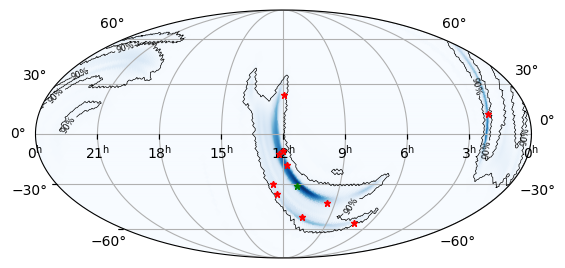

In [10]:
ax = plt.figure().add_subplot(111, projection="astro mollweide")
# plot 90% contour
add_contour(skymap, level=[90], fig=ax)
# plot skymap
ax.imshow_hpx((skymap, "ICRS"), vmin=0, order="nearest-neighbor", cmap='Blues')
# Plot sampled locations
for ra_, dec_ in zip(ra[:-1], dec[:-1]):
    ax.plot_coord(
        SkyCoord(ra_, dec_, unit=u.deg),
        "*",
        markerfacecolor="red",
        markeredgecolor="red",
        markersize=5,
    )
ax.plot_coord(SkyCoord(ra[-1], dec[-1], unit=u.deg), "*", 
              markerfacecolor="green", markeredgecolor="green", markersize=5)
add_edges()

In [11]:
OpSimSurv = opsim.OpSimSurvey("/fred/oz016/bgao_kn/data/rubin_sim/baseline/baseline_v5.0.1_10yrs.db")

Reading from database sqlite:////fred/oz016/bgao_kn/data/rubin_sim/baseline/baseline_v5.0.1_10yrs.db
Read N = 2092088 observations in 43.37 seconds.
No host file.


Finished compute healpy representation, total number of fields : 1560341.


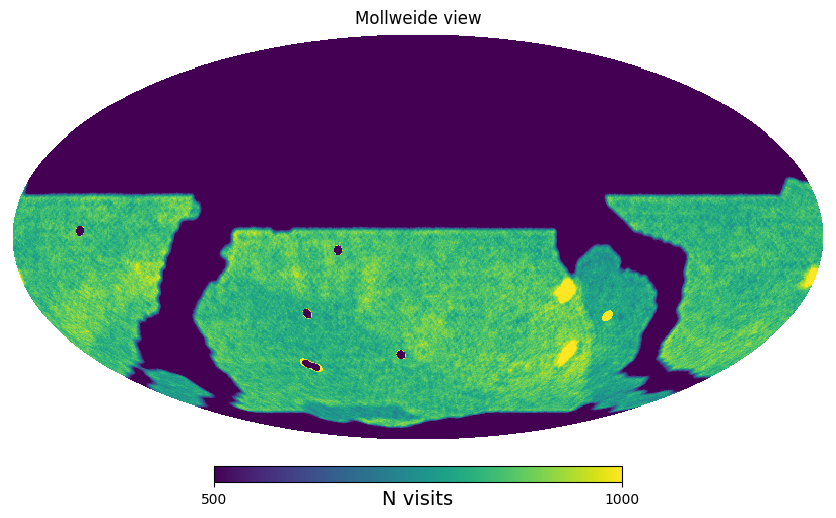

In [12]:
# Compute the healpy representation of the survey
# with a cut to a minimum of 500 and a maximum of 10000 visits
nsides = 512
OpSimSurv.compute_hp_rep(nside=nsides)

# Plot the healpy configuration
fig = OpSimSurv.plot_hp_rep(min=500, max=1000)

In [14]:
hp_rep = OpSimSurv.hp_rep
hp_rep.head()

,hp_ra,hp_dec,n_visits,field_label
ipix,,,,
987173,3.256641,0.381589,504,WFD
987175,3.262777,0.381589,509,WFD
987176,3.265845,0.381589,511,WFD
987177,3.268913,0.381589,506,WFD
987178,3.271981,0.381589,523,WFD


In [15]:
phi = np.radians(ra)
theta = np.radians(90.0-dec)
pix = hp.ang2pix(nsides, theta, phi, nest=True)
print(pix)
targets_hp = hp_rep[hp_rep.index.isin(pix)].copy()
targets_hp

[1671798 1133731 1606801 1770598  987802 2478981 2466853 1158762 1017663
   41542 2457459]


,hp_ra,hp_dec,n_visits,field_label
ipix,,,,
1158762,1.897534,0.266152,715,WFD
1606801,0.444854,-0.022137,880,WFD
1770598,0.312932,-0.126640,876,WFD
2457459,2.710544,-0.597406,841,WFD
2466853,0.113515,-0.605302,878,WFD
2478981,5.907360,-0.613241,847,WFD


In [16]:
OpSimSurv.sample_coordinates(ra, dec, nsides=nsides, is_deg=True)

In [17]:
# Writing simlib
sim = opsim.sim_io.SNANA_Simlib(OpSimSurv, out_path='/fred/oz016/bgao_kn/data/simlib/', file_suffix="_test")
sim.write_SIMLIB()

Writing SIMLIB in /fred/oz016/bgao_kn/data/simlib/baseline_v5.0.1_10yrs_test.SIMLIB
SIMLIB wrote in 1.17 sec.



In [ ]:
# Get the observations at a given RA, Dec
# ra = np.array([50.0, 150.0])
# dec = np.array([-30.0, -45.0])
Obs = OpSimSurv.get_obs_from_coords(ra, dec, is_deg=True)
Obs = list(Obs)
Obs[0]